# Clustering Penguins

**Dataset:** https://www.kaggle.com/datasets/youssefaboelwafa/clustering-penguins-species

This dataset contains measurements such as bill size, flipper length, and body mass for different penguins, but we do not know which species each penguin belongs to. Because of that, we will use clustering to  group similar penguins based on their features and see whether distinct penguin species can be identified solely from their physical characteristics.

## Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Data

In [2]:
df = pd.read_csv("../data/penguins.csv")

df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


## Removing Duplicates and Missing Values

In [3]:
df.duplicated().any()

np.True_

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df.isna().sum()

culmen_length_mm     1
culmen_depth_mm      1
flipper_length_mm    1
body_mass_g          1
sex                  8
dtype: int64

In [6]:
df.dropna(inplace=True)

Let us confirm the categories in the `sex` column.

In [7]:
df["sex"].unique()

<StringArray>
['MALE', 'FEMALE', '.']
Length: 3, dtype: str

In [8]:
df["sex"].value_counts()

sex
MALE      169
FEMALE    165
.           1
Name: count, dtype: int64

`"."` is not a real category, it’s just a placeholder for missing or unknown data. Before doing any clustering, we should clean this.

In [9]:
df = df[df["sex"] != "."]

In [10]:
df["sex"].unique()

<StringArray>
['MALE', 'FEMALE']
Length: 2, dtype: str

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   334 non-null    float64
 1   culmen_depth_mm    334 non-null    float64
 2   flipper_length_mm  334 non-null    float64
 3   body_mass_g        334 non-null    float64
 4   sex                334 non-null    str    
dtypes: float64(4), str(1)
memory usage: 15.7 KB


## Removing Outliers

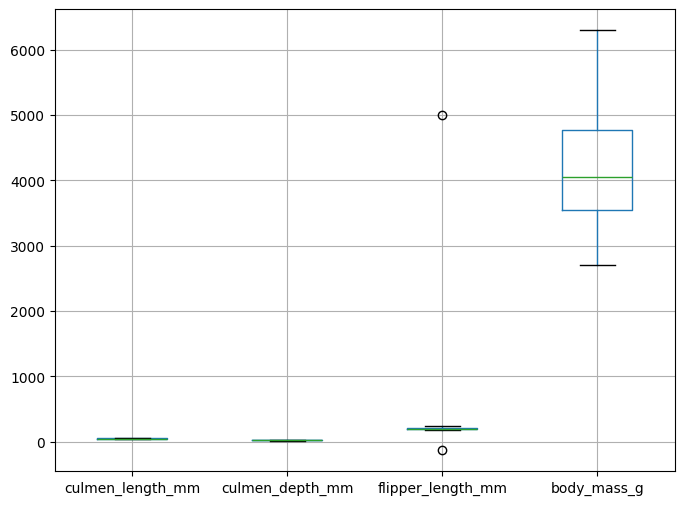

In [12]:
plt.figure(figsize=(8, 6))
df.boxplot()
plt.show()

`flipper_length_mm` contains some unrealistic values. Imagine a penguin with a 5000mm (5 metres) flipper or one with negative length, which are physically impossible. These are clear signs of data errors and should either be removed or corrected to better reflect realistic penguin measurements.

In [13]:
df = df.query("flipper_length_mm <= 4000 and flipper_length_mm >= 0")

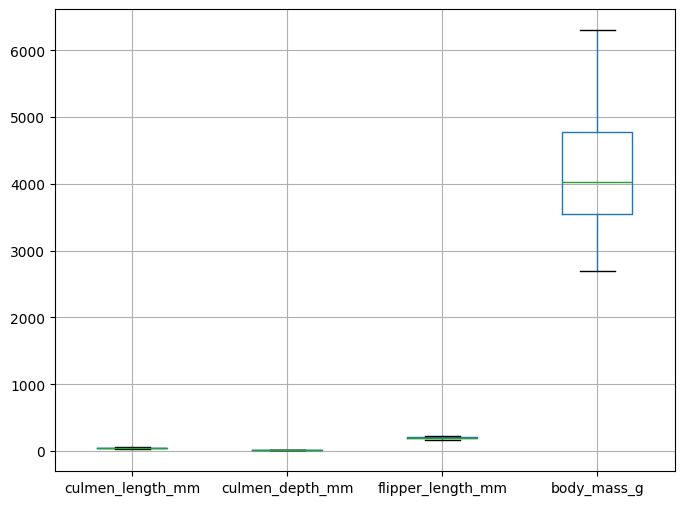

In [14]:
plt.figure(figsize=(8, 6))
df.boxplot()
plt.show()

## Encoding Categorical Data

In [15]:
df = pd.get_dummies(df)

In [16]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True
1,39.5,17.4,186.0,3800.0,True,False
2,40.3,18.0,195.0,3250.0,True,False
4,36.7,19.3,193.0,3450.0,True,False
5,39.3,20.6,190.0,3650.0,False,True


## Scaling Numerical Data

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

## Principal Component Analysis (PCA)

Principal component analysis (PCA) is a linear dimensionality reduction technique.

It works by transforming high-dimensional data into a lower-dimensional space while maximizing the variance (or spread) of the data in the new space.

**NOTE:** It works best when the data is scaled

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

## Getting the Features

In [19]:
X = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])

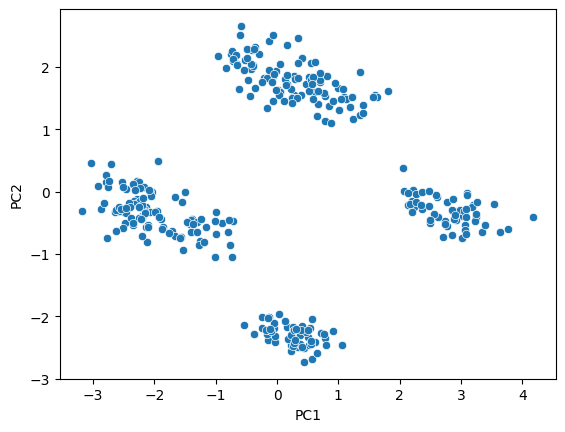

In [20]:
sns.scatterplot(data=X, x="PC1", y="PC2")
plt.show()

## Elbow Method

In [21]:
from sklearn.cluster import KMeans

In [22]:
inertias = []

for k in range(1, 11):
    k_means = KMeans(n_clusters=k, random_state=42)
    k_means.fit(X)
    inertias.append(k_means.inertia_)

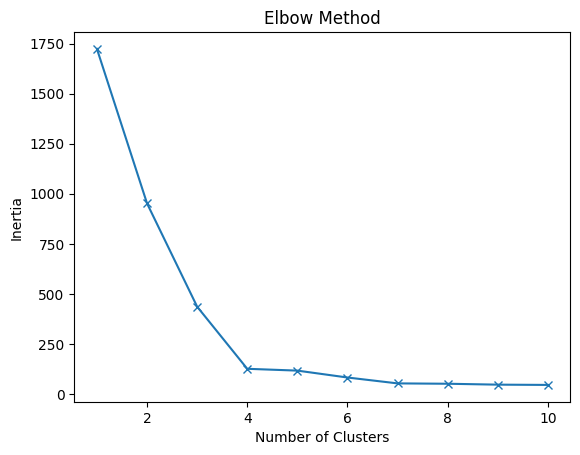

In [23]:
plt.plot(range(1, 11), inertias, marker='x')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

`4` is the elbow point.

## Training the Model

In [24]:
k_means = KMeans(n_clusters=4, random_state=42)
k_means.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)","[

## Visualization

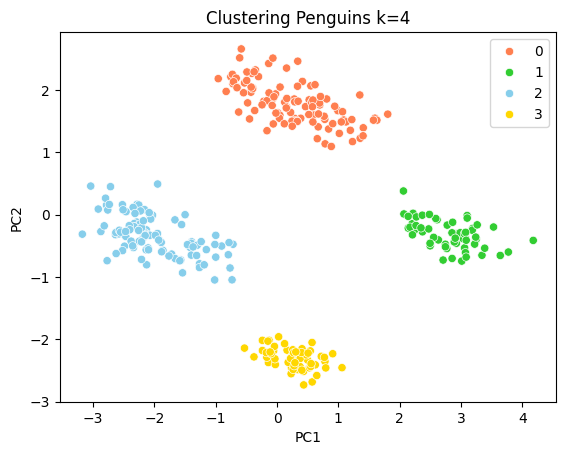

In [25]:
sns.scatterplot(data=X, x="PC1", y="PC2", hue=k_means.labels_, palette=["coral", "limegreen", "skyblue", "gold"])
plt.title("Clustering Penguins k=4")
plt.show()

From what we see, we can infer that the data likely contains four different species that were recorded,

## Evaluation

In [26]:
from sklearn.metrics import silhouette_score

silhouette_score(X, k_means.labels_)

0.7421034438118217

## Assignment

**Dataset:** https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering

This dataset is based on chemical measurements taken from wines produced in the same region in Italy but originating from different cultivars.

You should explore and clean the data, understand the relationships between the features, and then apply clustering techniques to group the wines based on their chemical composition.